<a href="https://colab.research.google.com/github/Bhargavnaik711/HibernateCriteriaQueryProject/blob/main/BDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
#Step 1: Load & Prepare Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# Load dataset
file_path = "/content/ai4i2020.csv"
df = pd.read_csv(file_path)

# Drop unnecessary columns
df = df.drop(columns=['UDI', 'Product ID', 'Type'])  # Removing non-numeric columns

# Define features (X) and target (y)
X = df.drop(columns=['Machine failure'])  # Sensor readings
y = df['Machine failure']  # Target variable

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print dataset info
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 8000
Testing samples: 2000


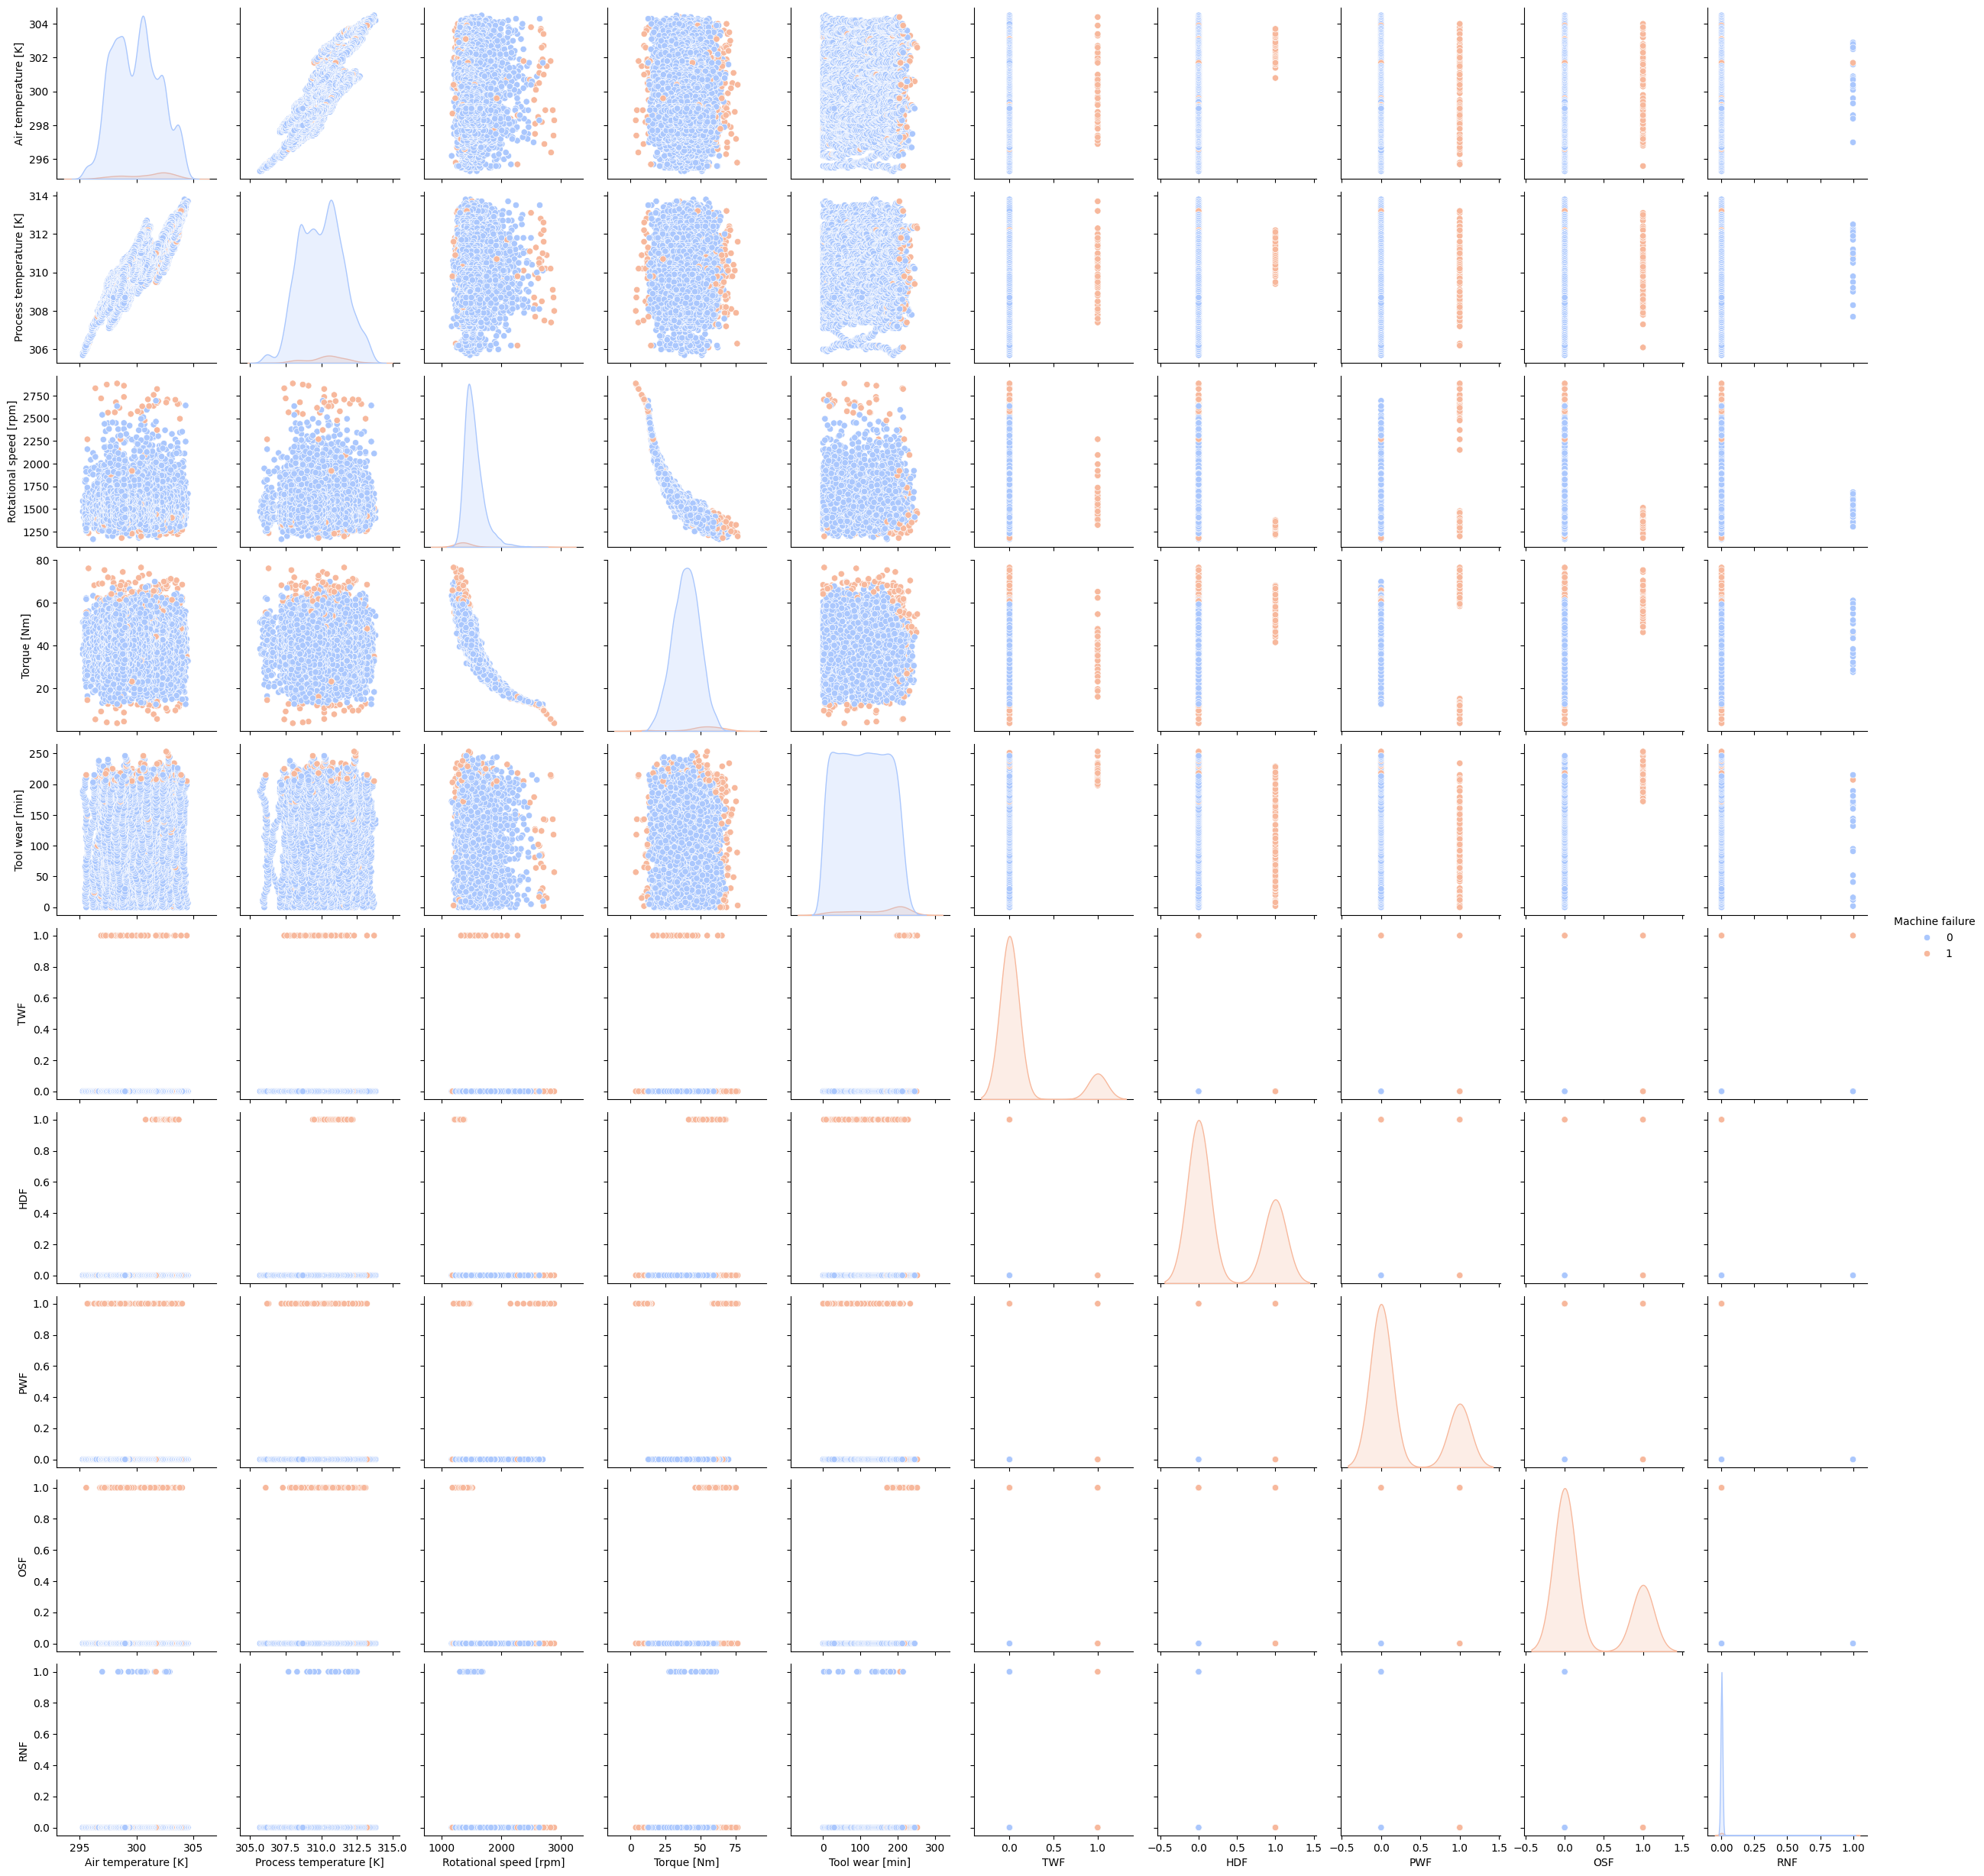

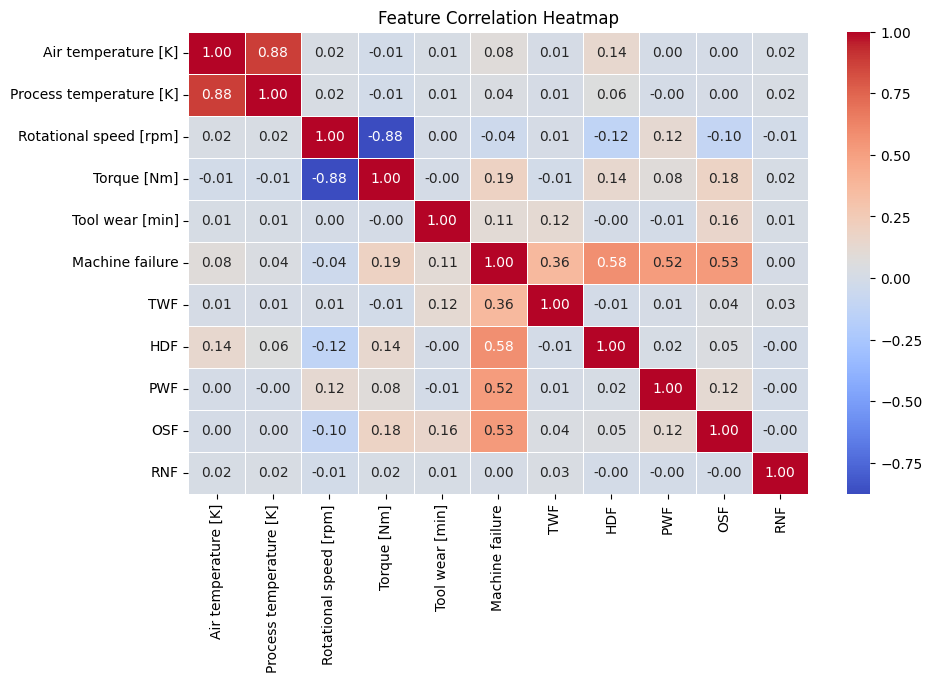

<ipython-input-14-6b7e7c6d264c>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Machine failure"], palette="coolwarm")


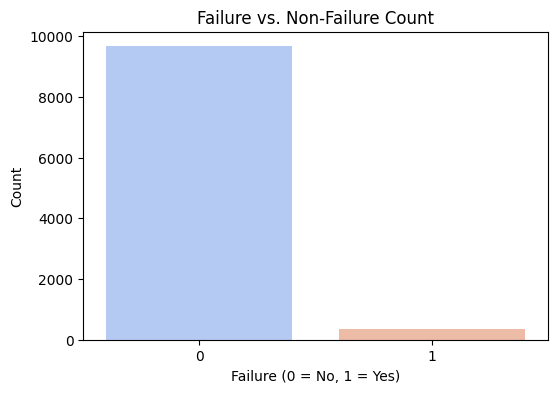

In [ ]:
#Step 2: Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot to visualize sensor data and failures
sns.pairplot(df, hue="Machine failure", diag_kind="kde", palette="coolwarm")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution of Failures
plt.figure(figsize=(6,4))
sns.countplot(x=df["Machine failure"], palette="coolwarm")
plt.title("Failure vs. Non-Failure Count")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE  # Handles class imbalance
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Drop weak features (if identified from heatmap)
X = df.drop(columns=['Machine failure', 'TWF', 'HDF', 'RNF'])  # Example of removing weak features
y = df['Machine failure']

# Handle class imbalance using SMOTE (if failures are rare)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Optimize Random Forest parameters
rf_model = RandomForestClassifier(
    n_estimators=200,  # More trees improve performance
    max_depth=10,  # Limits complexity (avoids overfitting)
    min_samples_split=5,  # Prevents very deep trees
    class_weight="balanced",  # Handles imbalance
    random_state=42
)

# Cross-validation for robustness
cv_scores = cross_val_score(rf_model, X_resampled, y_resampled, cv=5, scoring="accuracy")
print("Cross-Validation Accuracy:", np.mean(cv_scores))

# Train model
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
print("Final Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Cross-Validation Accuracy: 0.9066835271146537
Final Model Accuracy: 0.95627425614489

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      1934
           1       0.95      0.97      0.96      1931

    accuracy                           0.96      3865
   macro avg       0.96      0.96      0.96      3865
weighted avg       0.96      0.96      0.96      3865



In [ ]:
#Step 4: Save the Model
import joblib
sample_input = np.array([[300, 310, 1500, 45, 10, 0, 0]])
loaded_model = joblib.load('rf_model.pkl')

print("Predicted Failure:", loaded_model.predict(sample_input)[0])

Predicted Failure: 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.preprocessing import OrdinalEncoder # Import OrdinalEncoder

# Load the data
df = pd.read_csv("/content/ai4i2020.csv")

# Separate features and target
X = df.drop(columns=['Machine failure'])  # Features
y = df['Machine failure']  # Target variable

# Identify categorical features (columns with string values)
categorical_features = X.select_dtypes(include=['object']).columns

# Create an OrdinalEncoder
encoder = OrdinalEncoder()

# Fit the encoder on the categorical features and transform them
X[categorical_features] = encoder.fit_transform(X[categorical_features])

# Splitting into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)

# Accuracy Score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.999
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
 [[1939    0]
 [   2   59]]


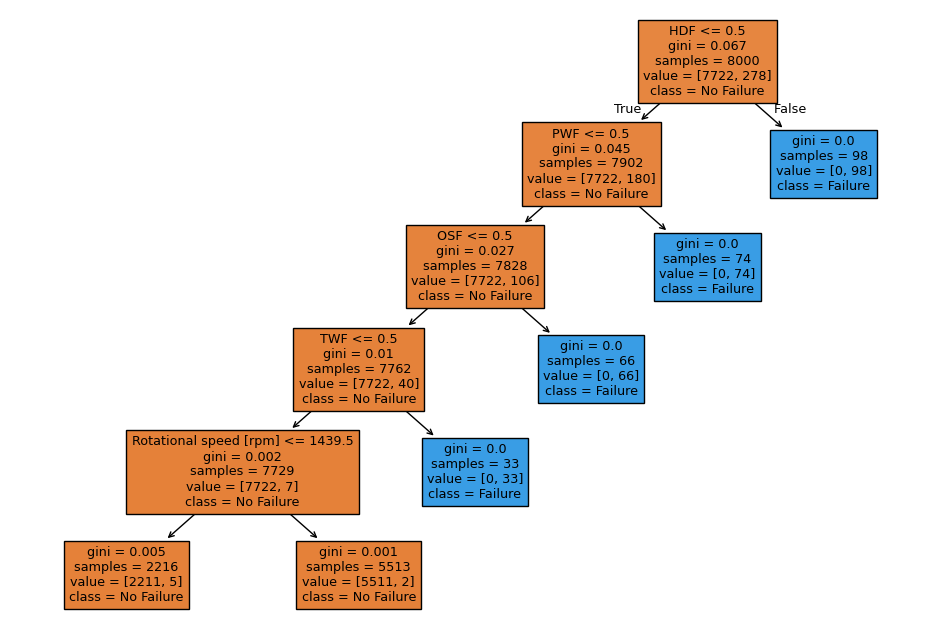

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=["No Failure", "Failure"], filled=True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df = pd.read_csv("/content/ai4i2020.csv")

In [ ]:
X = df.drop(columns=['Machine failure'])  # Features
y = df['Machine failure']  # Target variable (0 or 1)

# Splitting into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder


df = pd.read_csv("/content/ai4i2020.csv")

# Drop unnecessary columns (including 'Product ID')
X = df.drop(columns=['Machine failure', 'Product ID'])  # Features + dropping 'Product ID'
y = df['Machine failure']  # Target variable (0 or 1)

# Identify categorical features (columns with string values)
categorical_features = X.select_dtypes(include=['object']).columns

# Create a LabelEncoder for each categorical feature
for feature in categorical_features:
    le = LabelEncoder()
    X[feature] = le.fit_transform(X[feature])

# Splitting into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = log_reg.predict(X_test)

# Accuracy Score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.999
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
 [[1939    0]
 [   2   59]]


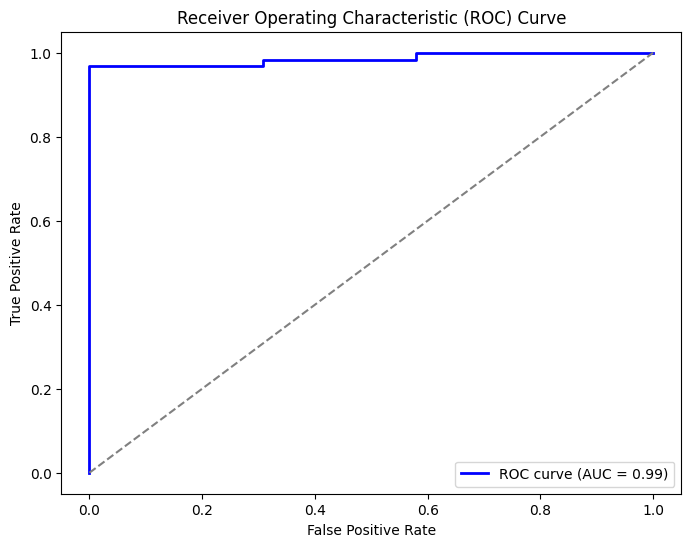

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Predict probabilities
y_prob = log_reg.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM model (using RBF kernel)
svm_model = SVC(kernel='rbf', probability=True)

# Train the model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.99


In [ ]:
# Initialize the SVM model (using RBF kernel)
svm_model = SVC(kernel='rbf', probability=True)

# Train the model - This line is redundant and should be removed
# svm_model = SVC(kernel='linear')

# Remove the redundant initialization to avoid overriding the model with the wrong kernel:
svm_model.fit(X_train, y_train)

SVC(probability=True)

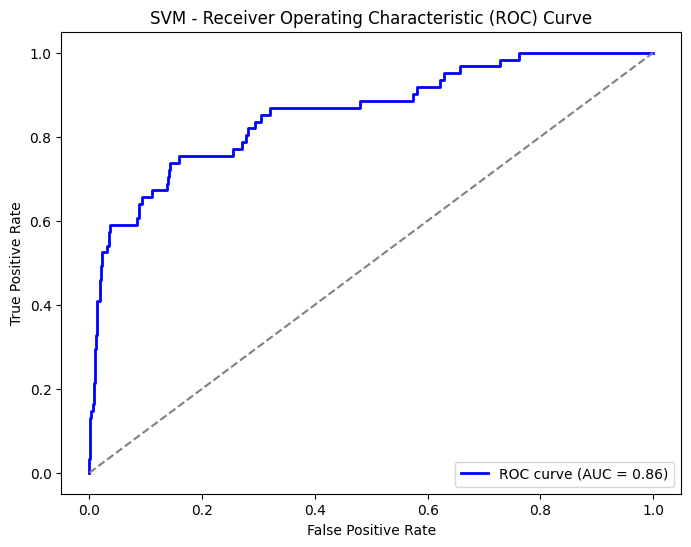

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probabilities
y_prob = svm_model.predict_proba(X_test)[:, 1]

# Compute ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

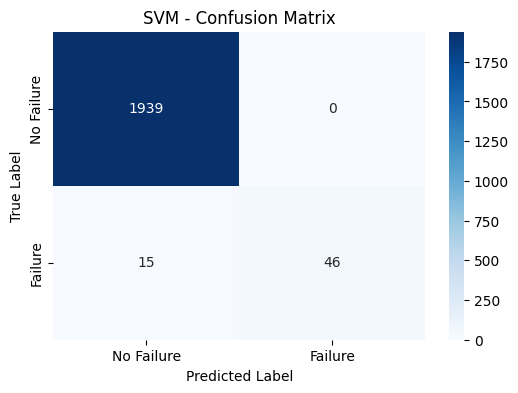

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM - Confusion Matrix')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

# Initialize Models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='rbf', probability=True)

# Train Models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# Probabilities for AUC
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Calculate Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Calculate AUC Score
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_svm = roc_auc_score(y_test, y_prob_svm)

# Print Results
print("Model Performance Comparison:")
print(f"Decision Tree  - Accuracy: {accuracy_dt:.2f}, AUC: {auc_dt:.2f}")
print(f"Random Forest  - Accuracy: {accuracy_rf:.2f}, AUC: {auc_rf:.2f}")
print(f"Logistic Reg.  - Accuracy: {accuracy_lr:.2f}, AUC: {auc_lr:.2f}")
print(f"SVM            - Accuracy: {accuracy_svm:.2f}, AUC: {auc_svm:.2f}")

# Find Best Model
best_model = max([(accuracy_dt, 'Decision Tree'), (accuracy_rf, 'Random Forest'),
                  (accuracy_lr, 'Logistic Regression'), (accuracy_svm, 'SVM')])

print(f"\nBest Model: {best_model[1]} with Accuracy {best_model[0]:.2f}")


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Performance Comparison:
Decision Tree  - Accuracy: 1.00, AUC: 0.98
Random Forest  - Accuracy: 1.00, AUC: 0.98
Logistic Reg.  - Accuracy: 1.00, AUC: 0.99
SVM            - Accuracy: 0.97, AUC: 0.86

Best Model: Random Forest with Accuracy 1.00


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

# Initialize Models
dt_model = DecisionTreeClassifier(random_state=42) # Define dt_model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='rbf', probability=True)

# Train Models
dt_model.fit(X_train, y_train) # Train dt_model
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)


feature_importance_dt = pd.Series(dt_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_importance_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Feature Importance for Decision Tree:")
print(feature_importance_dt)

print("\nFeature Importance for Random Forest:")
print(feature_importance_rf)

feature_importance_lr = pd.Series(lr_model.coef_[0], index=X_train.columns).sort_values(ascending=False)

print("\nFeature Importance for Logistic Regression:")
print(feature_importance_lr)


Feature Importance for Decision Tree:
HDF                        0.309925
PWF                        0.294411
OSF                        0.239894
TWF                        0.129058
Air temperature [K]        0.010499
Tool wear [min]            0.005508
Torque [Nm]                0.004047
Process temperature [K]    0.003692
Rotational speed [rpm]     0.002967
RNF                        0.000000
dtype: float64

Feature Importance for Random Forest:
HDF                        0.273129
OSF                        0.229276
PWF                        0.214592
TWF                        0.115935
Torque [Nm]                0.065772
Rotational speed [rpm]     0.042468
Tool wear [min]            0.026458
Air temperature [K]        0.016894
Process temperature [K]    0.015210
RNF                        0.000266
dtype: float64

Feature Importance for Logistic Regression:
HDF                        7.289567
TWF                        6.794708
OSF                        6.121425
PWF                 

In [ ]:
svm_model = SVC(kernel='linear', probability=True) # Changed kernel to 'linear'

# Fit the model before accessing coef_
svm_model.fit(X_train, y_train)

feature_importance_svm = pd.Series(abs(svm_model.coef_[0]), index=X_train.columns).sort_values(ascending=False)

print("\nFeature Importance for SVM:")
print(feature_importance_svm)


Feature Importance for SVM:
PWF                        5.441815
TWF                        5.000000
HDF                        4.941622
OSF                        4.469636
Process temperature [K]    0.085500
Torque [Nm]                0.039603
Air temperature [K]        0.023932
Tool wear [min]            0.002967
Rotational speed [rpm]     0.000798
RNF                        0.000000
dtype: float64


In [ ]:
import pandas as pd
# Assuming feature_importance_dt, feature_importance_rf, feature_importance_lr, and feature_importance_svm
# are already calculated as in the provided code.

def compare_feature_importance(dt_fi, rf_fi, lr_fi, svm_fi):
    """Compares feature importance across different models."""

    # Concatenate feature importance series into a DataFrame
    comparison_df = pd.DataFrame({
        'Decision Tree': dt_fi,
        'Random Forest': rf_fi,
        'Logistic Regression': lr_fi,
        'SVM': svm_fi
    })

    # Calculate the average feature importance across all models.
    comparison_df['Average Importance'] = comparison_df.mean(axis=1)

    # Sort by average importance
    comparison_df = comparison_df.sort_values('Average Importance', ascending=False)

    return comparison_df

# Call the function to compare feature importances
comparison_result = compare_feature_importance(feature_importance_dt, feature_importance_rf,
                                               feature_importance_lr, feature_importance_svm)

# Display the comparison
print("\nComparison of Feature Importance across Models:")
print(comparison_result)

# Determine the most important feature based on average importance
most_important_feature = comparison_result.index[0]
print(f"\nMost important feature (based on average importance): {most_important_feature}")



Comparison of Feature Importance across Models:
                         Decision Tree  Random Forest  Logistic Regression  \
HDF                           0.309925       0.273129             7.289567   
TWF                           0.129058       0.115935             6.794708   
PWF                           0.294411       0.214592             5.824248   
OSF                           0.239894       0.229276             6.121425   
Air temperature [K]           0.010499       0.016894             0.378798   
Torque [Nm]                   0.004047       0.065772             0.155337   
RNF                           0.000000       0.000266             0.072276   
Rotational speed [rpm]        0.002967       0.042468             0.006524   
Tool wear [min]               0.005508       0.026458             0.007713   
Process temperature [K]       0.003692       0.015210            -0.440384   

                              SVM  Average Importance  
HDF                      4.941622   

<ipython-input-22-9fa2d70b6d5c>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='coolwarm')


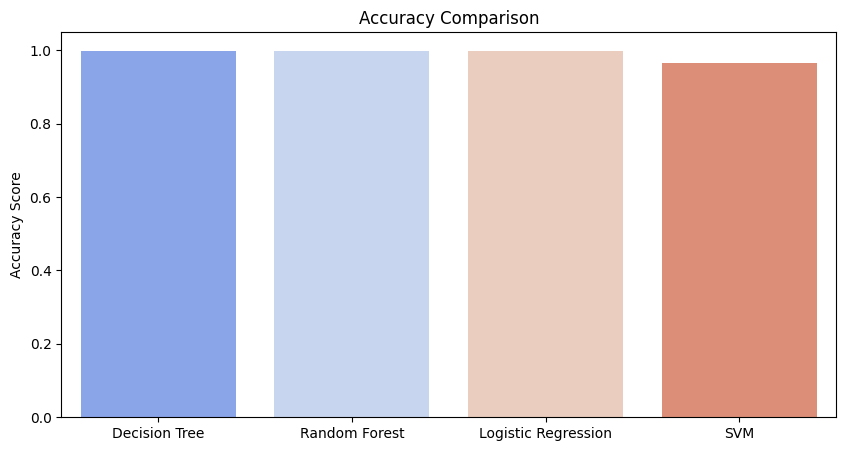

<ipython-input-22-9fa2d70b6d5c>:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=auc_scores, palette='coolwarm')


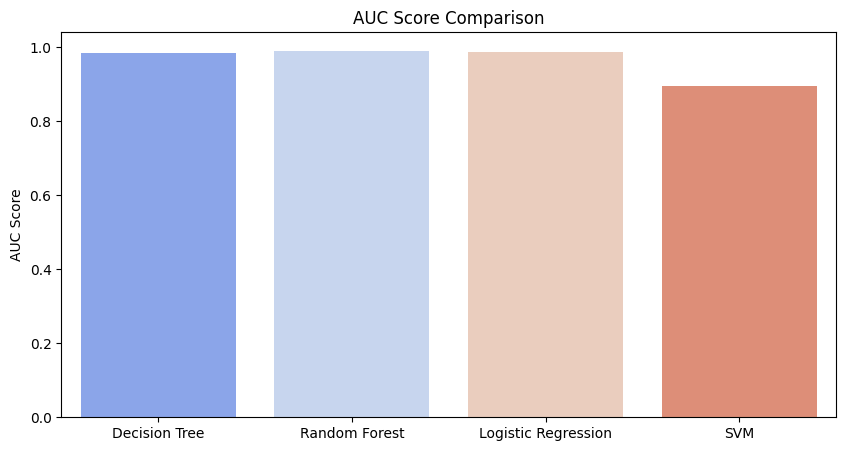

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

# Assuming X_train, X_test, y_train, y_test are already defined

# Initialize and train models (same as in ipython-input-0-e9e6e2455ac6)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='rbf', probability=True)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

# Predictions and probabilities (same as in ipython-input-0-e9e6e2455ac6)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Calculate Accuracy and AUC (same as in ipython-input-0-e9e6e2455ac6)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_svm = roc_auc_score(y_test, y_prob_svm)

# ... (Rest of the code from ipython-input-21-e9e6e2455ac6 for visualization)
# Data for visualization
models = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM']
accuracies = [accuracy_dt, accuracy_rf, accuracy_lr, accuracy_svm]
auc_scores = [auc_dt, auc_rf, auc_lr, auc_svm]

# Plot Accuracy
plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=accuracies, palette='coolwarm')
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.show()

# Plot AUC Score
plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=auc_scores, palette='coolwarm')
plt.title('AUC Score Comparison')
plt.ylabel('AUC Score')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Load dataset
file_path = "/content/ai4i2020.csv"
df = pd.read_csv(file_path)

# Drop unnecessary columns
df = df.drop(columns=['UDI', 'Product ID', 'Type'])  # Removing non-numeric columns

# Define features (X) and target (y)
X = df.drop(columns=['Machine failure'])  # Sensor readings
y = df['Machine failure']  # Target variable

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 15457
Testing samples: 3865


In [ ]:
# Get the current feature names (column names)
current_feature_names = X_train.columns

# Create a list of new feature names as strings, replacing invalid characters
new_feature_names = [str(name).replace('[', '').replace(']', '').replace('<', '') for name in current_feature_names]

# Replace the column names in the training data
X_train.columns = new_feature_names
X_test.columns = new_feature_names  # Also update for X_test for consistency

# Now you can train the XGBoost model
xgb_model.fit(X_train, y_train)


# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"XGBoost - Accuracy: {accuracy_xgb:.2f}, AUC: {auc_xgb:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost - Accuracy: 0.99, AUC: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1934
           1       0.99      0.99      0.99      1931

    accuracy                           0.99      3865
   macro avg       0.99      0.99      0.99      3865
weighted avg       0.99      0.99      0.99      3865



In [ ]:
from sklearn.metrics import roc_auc_score

# Assuming accuracy_dt, accuracy_rf, accuracy_lr, accuracy_svm, auc_dt, auc_rf, auc_lr, auc_svm, accuracy_xgb, auc_xgb  are already calculated

models = {
    'Decision Tree': (accuracy_dt, auc_dt),
    'Random Forest': (accuracy_rf, auc_rf),
    'Logistic Regression': (accuracy_lr, auc_lr),
    'SVM': (accuracy_svm, auc_svm),
    'XGBoost': (accuracy_xgb, auc_xgb)
}


best_model = max(models, key=lambda k: models[k][0]) # Find best by accuracy
print(f"Best model based on accuracy: {best_model} with accuracy {models[best_model][0]:.2f}")

best_auc_model = max(models, key=lambda k: models[k][1]) # Find best by AUC
print(f"Best model based on AUC: {best_auc_model} with AUC {models[best_auc_model][1]:.2f}")


Best model based on accuracy: Random Forest with accuracy 1.00
Best model based on AUC: XGBoost with AUC 1.00


In [ ]:
# prompt: give a code that prints the only one feature that is more effective on making machine failure

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the data
df = pd.read_csv("/content/ai4i2020.csv")

# Prepare the data (same preprocessing as in your original code)
X = df.drop(columns=['Machine failure', 'Product ID'])
y = df['Machine failure']

categorical_features = X.select_dtypes(include=['object']).columns

for feature in categorical_features:
    le = LabelEncoder()
    X[feature] = le.fit_transform(X[feature])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize and train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Print the most important feature
most_important_feature = feature_importances.idxmax()
print(f"The most effective feature for predicting machine failure is: {most_important_feature}")


The most effective feature for predicting machine failure is: HDF


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, class_weight="balanced", random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest - Accuracy: {accuracy_rf:.2f}, AUC: {auc_rf:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest - Accuracy: 0.97, AUC: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97      1934
           1       0.97      0.96      0.97      1931

    accuracy                           0.97      3865
   macro avg       0.97      0.97      0.97      3865
weighted avg       0.97      0.97      0.97      3865



<ipython-input-8-2a9a642e31db>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='coolwarm')


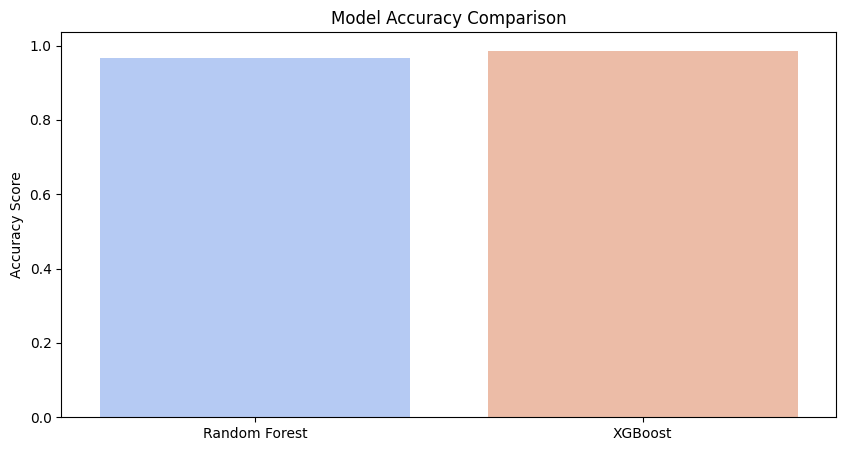

<ipython-input-8-2a9a642e31db>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=auc_scores, palette='coolwarm')


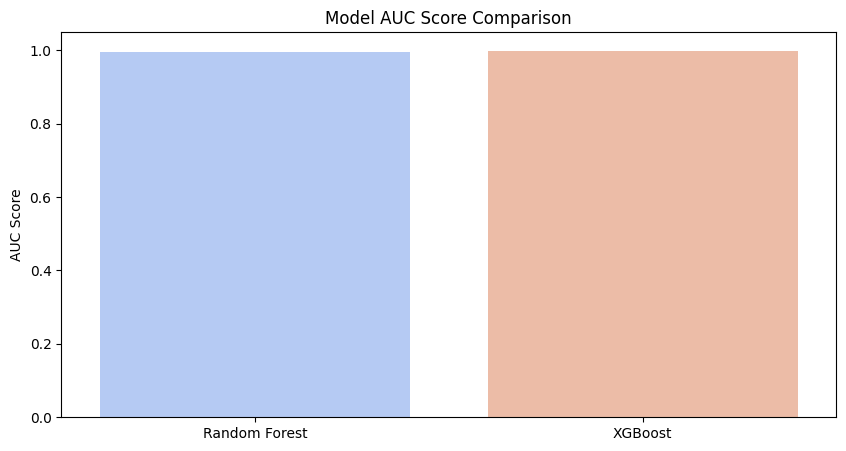

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for visualization
models = ['Random Forest', 'XGBoost']
accuracies = [accuracy_rf, accuracy_xgb]
auc_scores = [auc_rf, auc_xgb]

# Plot Accuracy
plt.figure(figsize=(10,5))
sns.barplot(x=models, y=accuracies, palette='coolwarm')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.show()

# Plot AUC Score
plt.figure(figsize=(10,5))
sns.barplot(x=models, y=auc_scores, palette='coolwarm')
plt.title("Model AUC Score Comparison")
plt.ylabel("AUC Score")
plt.show()

XGBoost - Accuracy: 0.99, AUC: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1934
           1       0.99      0.99      0.99      1931

    accuracy                           0.99      3865
   macro avg       0.99      0.99      0.99      3865
weighted avg       0.99      0.99      0.99      3865



<ipython-input-9-c06383259876>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='coolwarm')


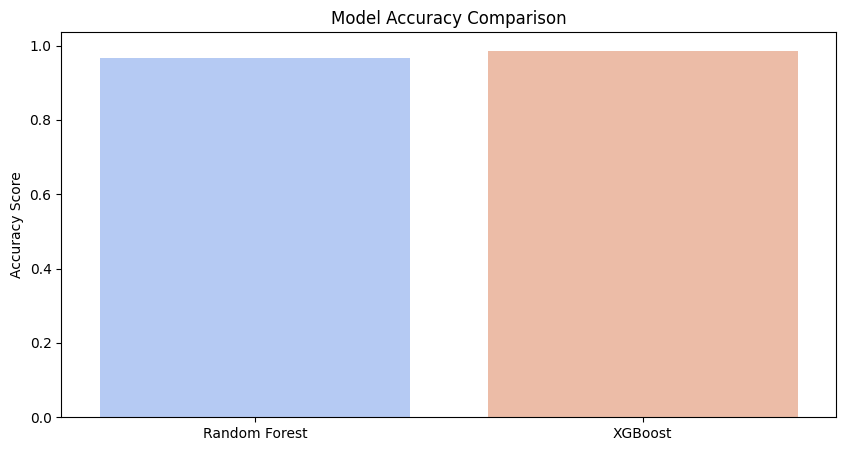

<ipython-input-9-c06383259876>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=auc_scores, palette='coolwarm')


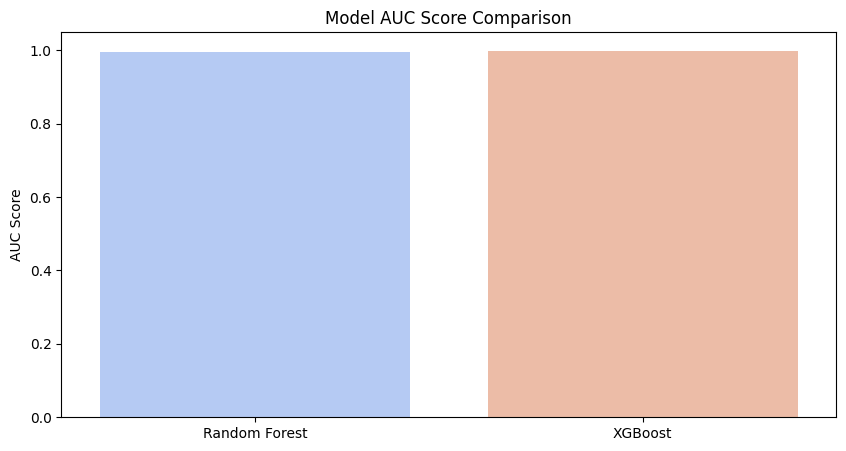

XGBoost performs better based on accuracy.
XGBoost performs better based on AUC.


In [ ]:
# prompt: give a code to compare and give which model is best in b/w random forest and xgboost

import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Assuming X_train, X_test, y_train, y_test are already defined from the previous code

# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# Calculate Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"XGBoost - Accuracy: {accuracy_xgb:.2f}, AUC: {auc_xgb:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# ... (rest of your existing code for RandomForest)


# Now compare XGBoost with RandomForest

# Data for visualization
models = ['Random Forest', 'XGBoost']
accuracies = [accuracy_rf, accuracy_xgb]
auc_scores = [auc_rf, auc_xgb]

# Plot Accuracy
plt.figure(figsize=(10,5))
sns.barplot(x=models, y=accuracies, palette='coolwarm')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.show()

# Plot AUC Score
plt.figure(figsize=(10,5))
sns.barplot(x=models, y=auc_scores, palette='coolwarm')
plt.title("Model AUC Score Comparison")
plt.ylabel("AUC Score")
plt.show()

# Determine the best model based on accuracy
if accuracy_rf > accuracy_xgb:
    print("Random Forest performs better based on accuracy.")
elif accuracy_xgb > accuracy_rf:
    print("XGBoost performs better based on accuracy.")
else:
    print("Both models have the same accuracy.")

# Determine the best model based on AUC
if auc_rf > auc_xgb:
    print("Random Forest performs better based on AUC.")
elif auc_xgb > auc_rf:
    print("XGBoost performs better based on AUC.")
else:
    print("Both models have the same AUC.")
